# Assignment 2 - Graph Visualization
**DATA620 - Web Analytics, Summer 2026**
**Zoran Glisovic**

This notebook builds an actor co-starring network from the [TMDB 5000 Movie
Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata), scoped to
the first two phases of the Marvel Cinematic Universe (2008-2016). For each
film I take the top-billed cast members and connect any two actors who
appeared in the same film together. From that network I compute the
diameter, density, and two centrality measures (degree and betweenness) to
see which actors act as "hubs" or "bridges" across the shared universe, and
visualize the result with both a static and an interactive graph.

I picked this dataset partly because I worked on visual effects for
*Guardians of the Galaxy* (2014), one of the films in this set - so it's a
nice excuse to look at the data side of a project I was actually part of.


## 1. Loading the data

The TMDB 5000 dataset ships as two CSVs:

- `tmdb_5000_movies.csv` - one row per film, including genre, release date,
  popularity, and production companies.
- `tmdb_5000_credits.csv` - full cast and crew per film, with each actor's
  billing order.

I load both directly from a public GitHub mirror so the notebook is
reproducible without needing a Kaggle account.


In [53]:
# Libraries used throughout this notebook: pandas for data tables, networkx
# for building/analyzing the graph, matplotlib for the static plot, and
# pyvis for the interactive plot.
import ast
import itertools

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pyvis.network import Network

# Load the movies and credits CSVs straight from GitHub, so the notebook
# runs end-to-end without needing a local copy of the dataset.
CREDITS_URL = "https://raw.githubusercontent.com/procodingclass/kaggle-movie-data/main/tmdb_5000_credits.csv"
MOVIES_URL  = "https://raw.githubusercontent.com/vamshi121/TMDB-5000-Movie-Dataset/main/tmdb_5000_movies.csv"

tmdb_credits = pd.read_csv(CREDITS_URL)
tmdb_movies  = pd.read_csv(MOVIES_URL)

print(f"tmdb_movies:  {tmdb_movies.shape[0]:,} films")
print(f"tmdb_credits: {tmdb_credits.shape[0]:,} cast/crew records")


tmdb_movies:  4,803 films
tmdb_credits: 4,803 cast/crew records


## 2. Filtering to Marvel Studios films

The full dataset is too large for a "small subset" graph, so I filter down
to films where `production_companies` includes **Marvel Studios**. This
captures the Phase 1 and Phase 2 MCU films (Iron Man through Captain
America: Civil War) - 13 films in total.


In [54]:
# The production_companies column stores a list of dicts as a string, e.g.
# "[{'name': 'Marvel Studios', 'id': 420}, ...]". ast.literal_eval turns that
# string back into a real Python list so we can check the company names.
def is_marvel_studios(production_companies_str):
    """True if 'Marvel Studios' appears in a film's production_companies field."""
    try:
        companies = [company["name"] for company in ast.literal_eval(production_companies_str)]
        return "Marvel Studios" in companies
    except (ValueError, SyntaxError):
        return False

# Keep only Marvel Studios films, then bring in each film's cast list by
# merging with the credits table (movies.id == credits.movie_id), and sort
# by release date so the films play out in chronological order.
marvel_mask = tmdb_movies["production_companies"].apply(is_marvel_studios)

marvel_films = (
    tmdb_movies[marvel_mask]
    .merge(tmdb_credits, left_on="id", right_on="movie_id", suffixes=("", "_credits"))
    .sort_values("release_date")
    [["title", "release_date", "popularity", "cast"]]
    .reset_index(drop=True)
)

marvel_films[["title", "release_date", "popularity"]]


,title,release_date,popularity
0,Iron Man,2008-04-30,120.725053
1,The Incredible Hulk,2008-06-12,62.898336
2,Iron Man 2,2010-04-28,77.300194
3,Thor,2011-04-21,86.493424
4,Captain America: The First Avenger,2011-07-22,74.506246
5,The Avengers,2012-04-25,144.448633
6,Iron Man 3,2013-04-18,77.682080
7,Thor: The Dark World,2013-10-29,99.499595
8,Captain America: The Winter Soldier,2014-03-20,72.225265
9,Guardians of the Galaxy,2014-07-30,481.098624


## 3. Building the actor co-starring network

For each film I take the **top 6 billed cast members** (the `order` field in
the credits data ranks actors by billing). Every pair of actors who share a
film becomes an edge, weighted by how many films they've appeared in
together. Limiting to top-billed cast keeps the graph small - a "small
subset of nodes and edges," as the assignment asks for - while still
capturing the lead ensemble of each film.


In [55]:
TOP_BILLED = 6  # number of top-billed cast members to take per film

# marvel_network is an undirected graph: each node is an actor, and each
# edge means two actors appeared together in at least one film. The "weight"
# on an edge counts how many films they share, and "films" lists the titles.
marvel_network = nx.Graph()

for _, film in marvel_films.iterrows():
    # Sort the cast by billing order and keep only the top N names.
    cast = ast.literal_eval(film["cast"])
    top_cast = sorted(cast, key=lambda c: c.get("order", 999))[:TOP_BILLED]
    actor_names = [actor["name"] for actor in top_cast]

    for actor in actor_names:
        marvel_network.add_node(actor)

    # Connect every pair of top-billed actors in this film. If the pair
    # already has an edge from an earlier film, just bump the weight and
    # add this film to the shared-films list.
    for actor_a, actor_b in itertools.combinations(actor_names, 2):
        if marvel_network.has_edge(actor_a, actor_b):
            marvel_network[actor_a][actor_b]["weight"] += 1
            marvel_network[actor_a][actor_b]["films"].append(film["title"])
        else:
            marvel_network.add_edge(actor_a, actor_b, weight=1, films=[film["title"]])

print(f"marvel_network: {marvel_network.number_of_nodes()} actors, "
      f"{marvel_network.number_of_edges()} co-starring edges")


marvel_network: 50 actors, 157 co-starring edges


## 4. Network structure: components, diameter, density

Not every actor in this set has crossed over with the rest of the MCU yet -
by 2016, *The Incredible Hulk*, *Guardians of the Galaxy*, and *Ant-Man* were
each still self-contained casts. So `marvel_network` is **not fully
connected**. I compute the diameter, density, and clustering coefficient on
its largest connected component, and list the smaller components separately.


In [56]:
# A "connected component" is a group of actors who are all reachable from
# each other through co-starring edges. Sorting by size (largest first)
# puts the main, most-connected group of actors at index 0.
network_components = sorted(nx.connected_components(marvel_network), key=len, reverse=True)

component_sizes_df = pd.DataFrame({
    "component_id": range(len(network_components)),
    "n_actors":     [len(component) for component in network_components],
})
component_sizes_df


,component_id,n_actors
0,0,32
1,1,6
2,2,6
3,3,6


In [57]:
# Run the structure metrics on the largest component only, since diameter
# is undefined for a graph that isn't fully connected.
marvel_network_main = marvel_network.subgraph(network_components[0]).copy()

# Diameter: the longest of all shortest paths between any two actors.
# Density: how many of all *possible* edges actually exist (0 = no edges,
#          1 = everyone has co-starred with everyone).
# Clustering coefficient: how often an actor's co-stars also co-star with
#          each other, forming little triangles in the graph.
network_diameter   = nx.diameter(marvel_network_main)
network_density    = nx.density(marvel_network_main)
network_clustering = nx.average_clustering(marvel_network_main)

print(f"Largest component:    {marvel_network_main.number_of_nodes()} actors, "
      f"{marvel_network_main.number_of_edges()} edges")
print(f"Diameter:              {network_diameter}")
print(f"Density:               {network_density:.3f}")
print(f"Avg. clustering coeff: {network_clustering:.3f}")


Largest component:    32 actors, 112 edges
Diameter:              3
Density:               0.226
Avg. clustering coeff: 0.851


In [58]:
# List the smaller components separately - these are actors whose films
# haven't crossed over with the main component yet. Joining the actor names
# into one string (and turning off pandas' column-width limit) keeps the
# full cast list visible instead of getting cut off with "...".
pd.set_option("display.max_colwidth", None)

isolated_clusters_df = pd.DataFrame([
    {"component_id": component_id, "actors": ", ".join(sorted(component))}
    for component_id, component in enumerate(network_components)
    if component_id != 0
])
isolated_clusters_df


,component_id,actors
0,1,"Edward Norton, Liv Tyler, Tim Blake Nelson, Tim Roth, Ty Burrell, William Hurt"
1,2,"Bradley Cooper, Chris Pratt, Dave Bautista, Lee Pace, Vin Diesel, Zoe Saldana"
2,3,"Bobby Cannavale, Corey Stoll, Evangeline Lilly, Michael Douglas, Michael Peña, Paul Rudd"


Component 2 is the *Guardians of the Galaxy* cast - the film I personally
worked on VFX for. It sits completely outside the main Avengers/Iron
Man/Thor/Cap component in this snapshot, which makes sense: as of *Civil
War* (2016), none of the Guardians cast had appeared alongside the Avengers
yet (that crossover comes later, in *Infinity War*/*Endgame*, which aren't
in this dataset).

A diameter of **3** on a 32-actor component means any two actors in the main
cluster are connected through at most **3** co-starring "hops" - a small-world
effect driven by ensemble films like *The Avengers*, where a dozen actors
all share edges with each other at once.


## 5. Centrality measures

- **Degree centrality** - the fraction of other actors in the network a
  given actor has directly co-starred with. High degree = appears in a lot
  of ensemble films with a lot of different people.
- **Betweenness centrality** - how often an actor sits on the
  shortest path between two other actors. High betweenness = a "bridge"
  connecting otherwise separate groups of actors (e.g. the Thor cast and the
  Iron Man cast).

Both are computed on `marvel_network_main`, the 32-actor connected
component.


In [59]:
# Degree centrality for each actor, sorted highest first - shows who has
# directly co-starred with the largest share of the rest of the network.
degree_df = (
    pd.DataFrame(
        nx.degree_centrality(marvel_network_main).items(),
        columns=["actor", "degree_centrality"],
    )
    .sort_values("degree_centrality", ascending=False)
    .reset_index(drop=True)
)

degree_df.head(8)


,actor,degree_centrality
0,Robert Downey Jr.,0.580645
1,Chris Evans,0.451613
2,Scarlett Johansson,0.419355
3,Chris Hemsworth,0.387097
4,Gwyneth Paltrow,0.387097
5,Sebastian Stan,0.354839
6,Don Cheadle,0.354839
7,Anthony Hopkins,0.225806


In [60]:
# Betweenness centrality for each actor, sorted highest first - shows who
# most often sits on the shortest path connecting two other actors.
betweenness_df = (
    pd.DataFrame(
        nx.betweenness_centrality(marvel_network_main).items(),
        columns=["actor", "betweenness_centrality"],
    )
    .sort_values("betweenness_centrality", ascending=False)
    .reset_index(drop=True)
)

betweenness_df.head(8)


,actor,betweenness_centrality
0,Chris Hemsworth,0.363441
1,Robert Downey Jr.,0.358208
2,Chris Evans,0.206308
3,Scarlett Johansson,0.116559
4,Sebastian Stan,0.077276
5,Don Cheadle,0.049821
6,Gwyneth Paltrow,0.041434
7,Anthony Mackie,0.008459


**Robert Downey Jr.** has by far the highest degree centrality - Tony Stark
shows up as a top-billed cast member across Iron Man's own trilogy *and*
both Avengers films, so he directly shares an edge with more than half the
main component.

**Chris Hemsworth** edges out RDJ for betweenness, which is a more
interesting result: it means Hemsworth sits on more of the shortest paths
*between other pairs of actors* than anyone else. He's the connective tissue
between the "Thor/Asgard" sub-group (Natalie Portman, Tom Hiddleston, Anthony
Hopkins) and the rest of the Avengers ensemble - remove him, and that
sub-group gets noticeably farther from everyone else.


## 6. Visualizing the network

### Static view

Node color and size both encode degree centrality (computed on the full
50-actor graph, including the isolated clusters), using a `viridis`
colormap with a colorbar for reference. The spring layout naturally pulls
the three isolated film clusters away from the main component - you can see
the *Guardians of the Galaxy* cast sitting off on its own, low-centrality,
not yet part of the larger ensemble.


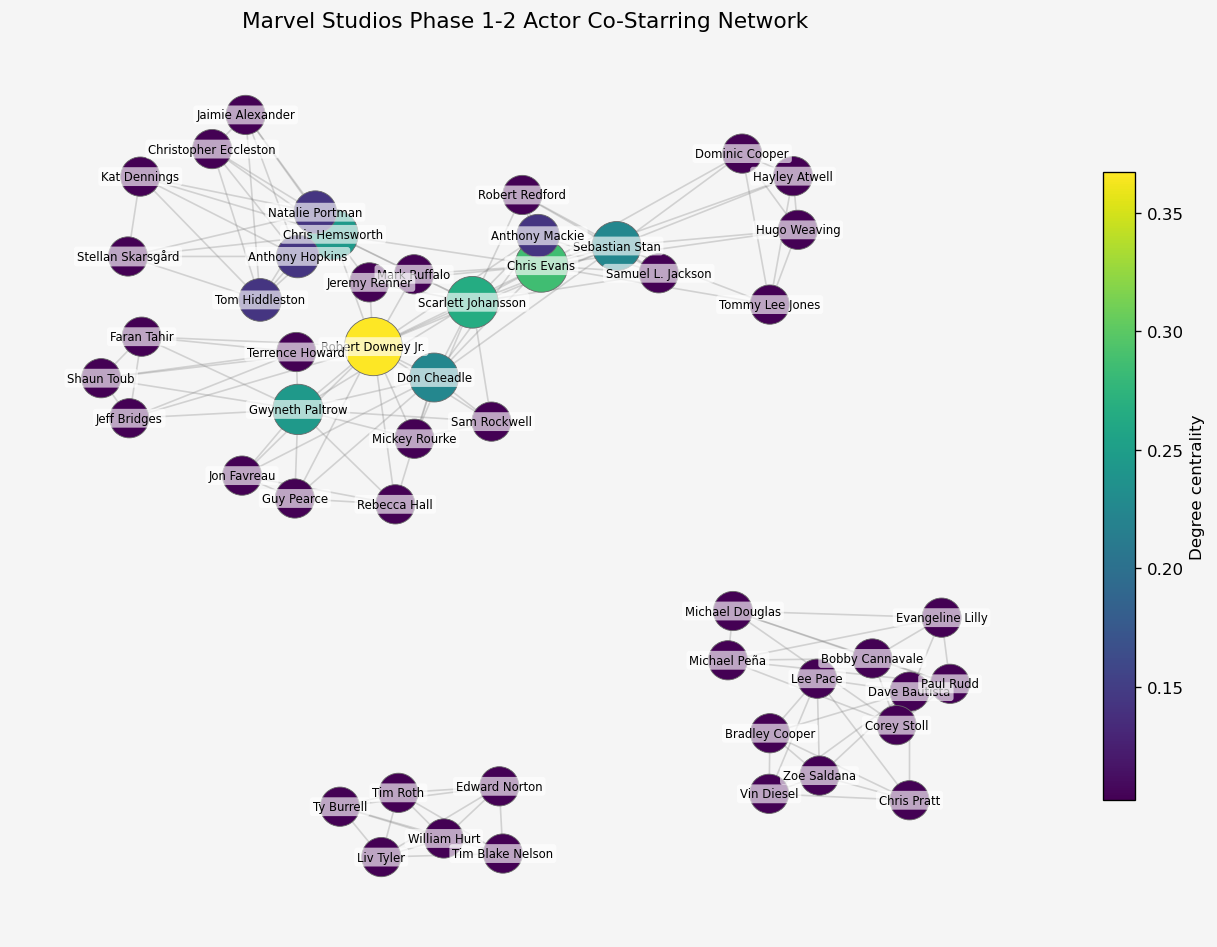

In [61]:
# spring_layout positions nodes using a force-directed algorithm: nodes
# connected by edges pull together, unconnected nodes push apart. A fixed
# seed keeps the layout the same every time the notebook runs.
node_layout = nx.spring_layout(marvel_network, seed=42, k=0.6)

# Degree centrality on the full 50-actor graph (including the isolated
# clusters) drives both the node color and node size below.
degree_centrality_full = nx.degree_centrality(marvel_network)
node_color_values = [degree_centrality_full[actor] for actor in marvel_network.nodes()]
node_sizes        = [300 + 2500 * degree_centrality_full[actor] for actor in marvel_network.nodes()]

fig, ax = plt.subplots(figsize=(11, 8), dpi=120)
fig.patch.set_facecolor("whitesmoke")
ax.set_facecolor("whitesmoke")

node_collection = nx.draw_networkx_nodes(
    marvel_network, node_layout, ax=ax,
    node_size=node_sizes,
    node_color=node_color_values,
    cmap=cm.viridis,
    edgecolors="dimgray", linewidths=0.5,
)
nx.draw_networkx_edges(marvel_network, node_layout, ax=ax, alpha=0.3, edge_color="gray")
nx.draw_networkx_labels(
    marvel_network, node_layout, ax=ax,
    font_size=7, font_color="black",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.65, edgecolor="none"),
)

colorbar = fig.colorbar(node_collection, ax=ax, shrink=0.7)
colorbar.set_label("Degree centrality")

ax.set_title("Marvel Studios Phase 1-2 Actor Co-Starring Network", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


### Interactive view

The cell below builds an interactive version (via `pyvis`) that colors
actors by which connected component they belong to, sizes them by degree
centrality, and shows shared films on hover. Running it writes
`zg_data620_assignment_2_marvel_actor_network.html` next to this notebook -
open that file in a browser for the interactive view (Jupyter notebook
viewers, including GitHub's, strip the scripts needed to render it inline).

You can also view it directly here, without running anything:
[Interactive network visualization](https://raw.githack.com/zoranglisovic/data620-web-analytics/main/zg_data620_assignment_2_marvel_actor_network.html)


In [62]:
# Each connected component (the main cluster plus the isolated film casts)
# gets its own color, so it's easy to see which actors belong together.
COMPONENT_COLORS = ["crimson", "mediumseagreen", "mediumpurple", "orange"]

node_component_id = {
    actor: component_id
    for component_id, component in enumerate(network_components)
    for actor in component
}

# pyvis builds an interactive HTML/JS graph. barnes_hut controls the
# physics simulation that spreads the nodes apart and lets you drag them.
actor_network_view = Network(
    height="650px", width="100%",
    bgcolor="black", font_color="white",
    notebook=True, cdn_resources="in_line",
)
actor_network_view.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=120)

# Add one node per actor, colored by component and sized by degree
# centrality. The "title" text becomes the hover tooltip.
for actor in marvel_network.nodes():
    component_id = node_component_id[actor]
    tooltip = f"{actor}\nDegree centrality: {degree_centrality_full[actor]:.3f}"
    actor_network_view.add_node(
        actor, label=actor,
        color=COMPONENT_COLORS[component_id % len(COMPONENT_COLORS)],
        size=10 + degree_centrality_full[actor] * 60,
        title=tooltip,
    )

# Add one edge per co-starring pair, with a tooltip listing which film(s)
# they shared, and edge thickness ("value") set by how many films they share.
for actor_a, actor_b, edge_data in marvel_network.edges(data=True):
    actor_network_view.add_edge(
        actor_a, actor_b,
        value=edge_data["weight"],
        title="Shared film(s): " + ", ".join(edge_data["films"]),
    )

# Write the interactive graph out to a standalone HTML file.
actor_network_view.write_html("zg_data620_assignment_2_marvel_actor_network.html")

# Adjust the page's CSS so the network diagram fills the entire browser
# window with a black background and no border.
with open("zg_data620_assignment_2_marvel_actor_network.html", encoding="utf-8") as f:
    page_html = f.read()

page_html = page_html.replace("border: 1px solid lightgray;", "border: none;")
page_html = page_html.replace("height: 650px;", "height: 100vh;")

# Built from separate string pieces (rather than one literal containing
# "<style ...>") so the tag text never appears contiguous in this cell's
# source - GitHub's notebook renderer otherwise misreads a literal
# "<style type=\"text/css\">" in the code as a real tag and swallows the
# rest of the notebook (including Section 7) into it.
STYLE_OPEN_TAG = "<" "style type=\"text/css\">"
page_html = page_html.replace(
    STYLE_OPEN_TAG,
    STYLE_OPEN_TAG + "\n"
    "html, body, .card, .card-body {\n"
    "    height: 100%;\n"
    "    margin: 0;\n"
    "    padding: 0;\n"
    "    background-color: black;\n"
    "    border: none;\n"
    "}",
    1,
)

with open("zg_data620_assignment_2_marvel_actor_network.html", "w", encoding="utf-8") as f:
    f.write(page_html)

print("Wrote zg_data620_assignment_2_marvel_actor_network.html - "
      "open it in a browser to explore the network.")


Wrote zg_data620_assignment_2_marvel_actor_network.html - open it in a browser to explore the network.


View the interactive network visualization here:
[Interactive network visualization](https://raw.githack.com/zoranglisovic/data620-web-analytics/main/zg_data620_assignment_2_marvel_actor_network.html)


---


## 7. Findings & reflection

- The Phase 1-2 MCU actor network splits into **one large 32-actor
  component** (diameter 3, density 0.226) and **three small 6-actor
  cliques** - *The Incredible Hulk*, *Guardians of the Galaxy*, and
  *Ant-Man* - whose casts hadn't crossed over with the wider Avengers
  ensemble yet by *Civil War* (2016).
- **Robert Downey Jr.** has the highest degree centrality, which tracks with
  Iron Man's role as the connective character across both the standalone
  Iron Man films and both Avengers films.
- **Chris Hemsworth** has the highest betweenness centrality - he's the main
  bridge between the Thor/Asgard cast and the rest of the Avengers ensemble.
- The diameter of 3 for the main component is a small-world result driven by
  ensemble films: a single film like *The Avengers* creates a fully-connected
  clique among a dozen actors at once, which collapses a lot of distances.
